---
title: Sentinel-1 GRD Geolocation with EOPFZARR Driver
subtitle: Ground Control Point (GCP) based geolocation for Sentinel-1 GRD products using the EOPFZARR GDAL driver
authors:
  - name: EOPF-Sample-Service Contributors
    github: EOPF-Sample-Service
    affiliations:
      - id: ESA
        institution: European Space Agency
date: 2026-02-05
thumbnail: ../static/EOPF-on-bright-baseline.png
keywords: ["sentinel-1", "GRD", "GCP", "geolocation", "GDAL", "EOPFZARR", "earth observation", "remote sensing"]
tags: ["sentinel-1", "gdal", "grd", "gcp"]
releaseDate: 2026-02-05
datePublished: 2026-02-05
dateModified: 2026-03-10
github: https://github.com/EOPF-Sample-Service/eopf-sample-notebooks
license: Apache-2.0
---


```{image} ../static/EOPF-on-bright-baseline.png
:alt: ESA EOPF Zarr Logo
:width: 250px
:align: center
```


# Sentinel-1 GRD Geolocation with EOPFZARR Driver


## Table of Contents

1. [Introduction](#Introduction)
2. [Setup](#Setup)
3. [Dataset Configuration](#DatasetConfig)
4. [Open a GRD Subdataset](#OpenDataset)
5. [Inspect GCPs](#InspectGCPs)
6. [Visualize GCP Grid](#VisualizeGCPs)
7. [Coordinate Transformation](#CoordTransform)
8. [Warp to Geographic Projection](#WarpProjection)
9. [GCPs on SLC Burst Subdatasets](#SLCBursts)
10. [Command Line Usage](#CommandLine)
11. [Summary](#Summary)


(Introduction)=
## Introduction

Sentinel-1 GRD (Ground Range Detected) products use **Ground Control Points (GCPs)** for geolocation — a sparse grid of pixel/line → longitude/latitude/height correspondences stored in `conditions/gcp/` arrays.

Unlike optical sensors (Sentinel-2/3) that use dense coordinate arrays or affine geotransforms, Sentinel-1 uses a **sparse grid of Ground Control Points** stored in `conditions/gcp/`:
- `pixel` (1D) and `line` (1D) define the image grid positions
- `latitude` (2D), `longitude` (2D), `height` (2D) define the geographic positions

The EOPFZARR driver **automatically reads** these arrays and attaches them as GDAL GCPs to measurement subdatasets, enabling reprojection and coordinate transformation.


:::{hint} Overview

**Questions**
- How does Sentinel-1 GRD geolocation work?
- How do I inspect and use Ground Control Points (GCPs)?
- How can I reproject Sentinel-1 data using GCPs?

**Objectives**
- Understand the GCP-based geolocation system used by Sentinel-1 GRD products.
- Inspect GCPs extracted from `conditions/gcp/` arrays.
- Transform pixel coordinates to geographic coordinates using GDAL's GCP transformer.
- Warp SAR data to WGS 84 using `gdal.Warp()` with GCP-based reprojection.
:::


(Setup)=
## Setup


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from osgeo import gdal, osr

gdal.UseExceptions()

print(f"GDAL version: {gdal.__version__}")

drv = gdal.GetDriverByName("EOPFZARR")
if drv:
    print("EOPFZARR driver: Registered")
else:
    print("WARNING: EOPFZARR driver not found!")

GDAL version: 3.12.0dev-209c099c56
EOPFZARR driver: Registered


(DatasetConfig)=
## Dataset Configuration

We use a Sentinel-1C IW mode GRD product with dual VV/VH polarization.


In [12]:
GRD_URL = (
    "/vsicurl/https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:"
    "notebook-data/tutorial_data/cpm_v264/"
    "S1C_IW_GRDH_1SDV_20260205T120122_20260205T120158_006220_00C7E4_5D6E.zarr"
)

zarr_path = f"EOPFZARR:'{GRD_URL}'"

print("Dataset: S1C_IW_GRDH_1SDV")
print("  Platform:      Sentinel-1C")
print("  Mode:          IW (Interferometric Wide)")
print("  Resolution:    High")
print("  Polarization:  Dual VV/VH")

Dataset: S1C_IW_GRDH_1SDV
  Platform:      Sentinel-1C
  Mode:          IW (Interferometric Wide)
  Resolution:    High
  Polarization:  Dual VV/VH


(OpenDataset)=
## Open a GRD Subdataset

We open the product with `GRD_MULTIBAND=NO` to access individual subdatasets, then open the VV measurement. GCPs are automatically attached to each measurement subdataset.


In [13]:
# Open product in standard mode to see subdatasets
root_ds = gdal.OpenEx(zarr_path, gdal.OF_RASTER, open_options=["GRD_MULTIBAND=NO"])

subdatasets = root_ds.GetMetadata("SUBDATASETS")

# Find the VV GRD measurement subdataset
vv_path = None
for key, value in sorted(subdatasets.items()):
    if "_NAME" in key and "measurements/grd" in value and "_VV" in value:
        vv_path = value
        break

print(f"VV subdataset: {vv_path.split(':/')[1] if vv_path else 'not found'}")

# Open the VV subdataset
ds = gdal.Open(vv_path)
print(f"\nDimensions: {ds.RasterXSize} x {ds.RasterYSize} pixels")
print(f"Data Type:  {gdal.GetDataTypeName(ds.GetRasterBand(1).DataType)}")

root_ds = None

VV subdataset: /objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:notebook-data/tutorial_data/cpm_v264/S1C_IW_GRDH_1SDV_20260205T120122_20260205T120158_006220_00C7E4_5D6E.zarr"

Dimensions: 25157 x 24285 pixels
Data Type:  UInt16


(InspectGCPs)=
## Inspect GCPs

The driver automatically extracts GCPs from the `conditions/gcp/` arrays and attaches them to the dataset.


In [14]:
gcp_count = ds.GetGCPCount()
print(f"GCP Count: {gcp_count}")

# Check the GCP spatial reference
gcp_srs = ds.GetGCPSpatialRef()
if gcp_srs:
    print(f"GCP SRS:   {gcp_srs.GetName()} (EPSG:{gcp_srs.GetAuthorityCode(None)})")

# Display the GCPs
gcps = ds.GetGCPs()
print("\nFirst 10 GCPs:")
print(
    f"{'ID':>6}  {'Pixel':>10}  {'Line':>10}  {'Longitude':>12}  {'Latitude':>12}  {'Height':>10}"
)
print("-" * 72)
for gcp in gcps[:10]:
    print(
        f"{gcp.Id:>6}  {gcp.GCPPixel:>10.1f}  {gcp.GCPLine:>10.1f}  "
        f"{gcp.GCPX:>12.4f}  {gcp.GCPY:>12.4f}  {gcp.GCPZ:>10.1f}"
    )

# Compute coverage
lons = [gcp.GCPX for gcp in gcps]
lats = [gcp.GCPY for gcp in gcps]
print("\nGeographic Extent:")
print(f"  Longitude: {min(lons):.4f} to {max(lons):.4f}")
print(f"  Latitude:  {min(lats):.4f} to {max(lats):.4f}")

GCP Count: 294
GCP SRS:   WGS 84 (EPSG:4326)

First 10 GCPs:
    ID       Pixel        Line     Longitude      Latitude      Height
------------------------------------------------------------------------
 GCP_1         0.5         0.5      -91.4153       16.2326       575.0
 GCP_2      1258.5         0.5      -91.5360       16.2558       905.0
 GCP_3      2516.5         0.5      -91.6550       16.2786      1133.0
 GCP_4      3774.5         0.5      -91.7738       16.3013      1370.0
 GCP_5      5032.5         0.5      -91.8912       16.3237      1513.0
 GCP_6      6290.5         0.5      -92.0058       16.3454      1443.0
 GCP_7      7548.5         0.5      -92.1269       16.3683      1883.9
 GCP_8      8806.5         0.5      -92.2429       16.3902      1936.9
 GCP_9     10064.5         0.5      -92.3516       16.4106      1372.0
GCP_10     11322.5         0.5      -92.4653       16.4319      1201.0

Geographic Extent:
  Longitude: -94.1458 to -91.4153
  Latitude:  14.0422 to 16.6654

(VisualizeGCPs)=
## Visualize GCP Grid

The GCPs form a sparse grid across the image. Let's visualize their distribution in both pixel space and geographic space.


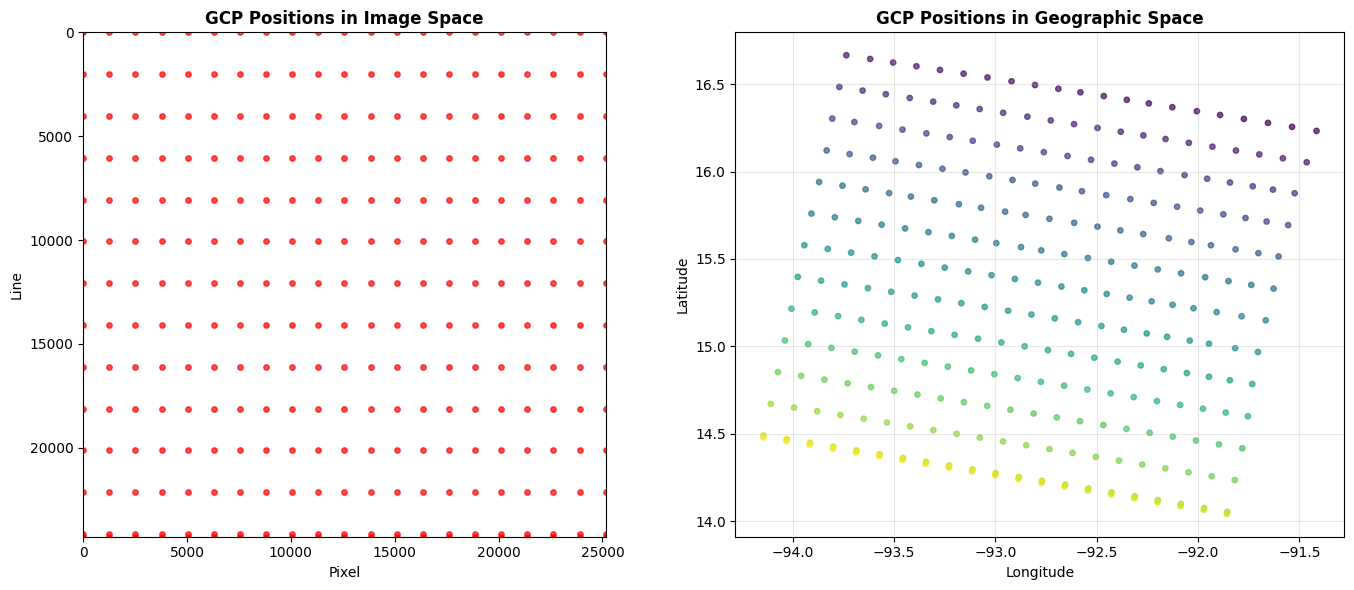

GCP grid: 21 columns x 14 rows = 294 points
Sampling: ~1 GCP every 1197 pixels (range) x 1734 pixels (azimuth)


In [15]:
pixels = [gcp.GCPPixel for gcp in gcps]
lines = [gcp.GCPLine for gcp in gcps]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: GCP positions in pixel space
axes[0].scatter(pixels, lines, c="red", s=15, alpha=0.7)
axes[0].set_xlim(0, ds.RasterXSize)
axes[0].set_ylim(ds.RasterYSize, 0)
axes[0].set_title("GCP Positions in Image Space", fontweight="bold")
axes[0].set_xlabel("Pixel")
axes[0].set_ylabel("Line")
axes[0].set_aspect("equal")

# Plot 2: GCP positions in geographic space
scatter = axes[1].scatter(
    lons, lats, c=range(len(lons)), cmap="viridis", s=15, alpha=0.7
)
axes[1].set_title("GCP Positions in Geographic Space", fontweight="bold")
axes[1].set_xlabel("Longitude")
axes[1].set_ylabel("Latitude")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compute grid dimensions
unique_pixels = len(set(int(p) for p in pixels))
unique_lines = len(set(int(ln) for ln in lines))
print(f"GCP grid: {unique_pixels} columns x {unique_lines} rows = {gcp_count} points")
print(
    f"Sampling: ~1 GCP every {ds.RasterXSize // unique_pixels} pixels (range)"
    f" x {ds.RasterYSize // unique_lines} pixels (azimuth)"
)

(CoordTransform)=
## Pixel-to-Geographic Coordinate Transformation

With GCPs attached, GDAL can transform between pixel coordinates and geographic coordinates using a GCP-based transformer.


In [16]:
# Create a GCP-based transformer
transformer = gdal.Transformer(ds, None, ["METHOD=GCP_POLYNOMIAL", "MAX_GCP_ORDER=3"])

# Transform image corners to geographic coordinates
corners = [
    ("Top-Left", 0, 0),
    ("Top-Right", ds.RasterXSize, 0),
    ("Bottom-Left", 0, ds.RasterYSize),
    ("Bottom-Right", ds.RasterXSize, ds.RasterYSize),
    ("Center", ds.RasterXSize // 2, ds.RasterYSize // 2),
]

print("Pixel-to-Geographic Coordinate Transformation:")
print(f"{'Location':<15} {'Pixel':>8} {'Line':>8}   {'Longitude':>12} {'Latitude':>12}")
print("-" * 65)
for name, px, ln in corners:
    success, result = transformer.TransformPoint(False, px, ln)
    if success:
        print(f"{name:<15} {px:>8} {ln:>8}   {result[0]:>12.4f} {result[1]:>12.4f}")
    else:
        print(f"{name:<15} {px:>8} {ln:>8}   transform failed")

Pixel-to-Geographic Coordinate Transformation:
Location           Pixel     Line      Longitude     Latitude
-----------------------------------------------------------------
Top-Left               0        0       -91.4285      16.2352
Top-Right          25157        0       -93.7365      16.6657
Bottom-Left            0    24285       -91.8581      14.0421
Bottom-Right       25157    24285       -94.1489      14.4795
Center             12578    12142       -92.7930      15.3590


(WarpProjection)=
## Warp to Geographic Projection

Using the GCPs, we can reproject the SAR data to a standard geographic projection (WGS 84). This is equivalent to what QGIS does when displaying GCP-based rasters.


Warped dataset: 1024 x 1060 pixels
GeoTransform:   origin=(14.0422, -91.4289), pixel size=(0.002563, -0.002563)
Projection:     GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,2...


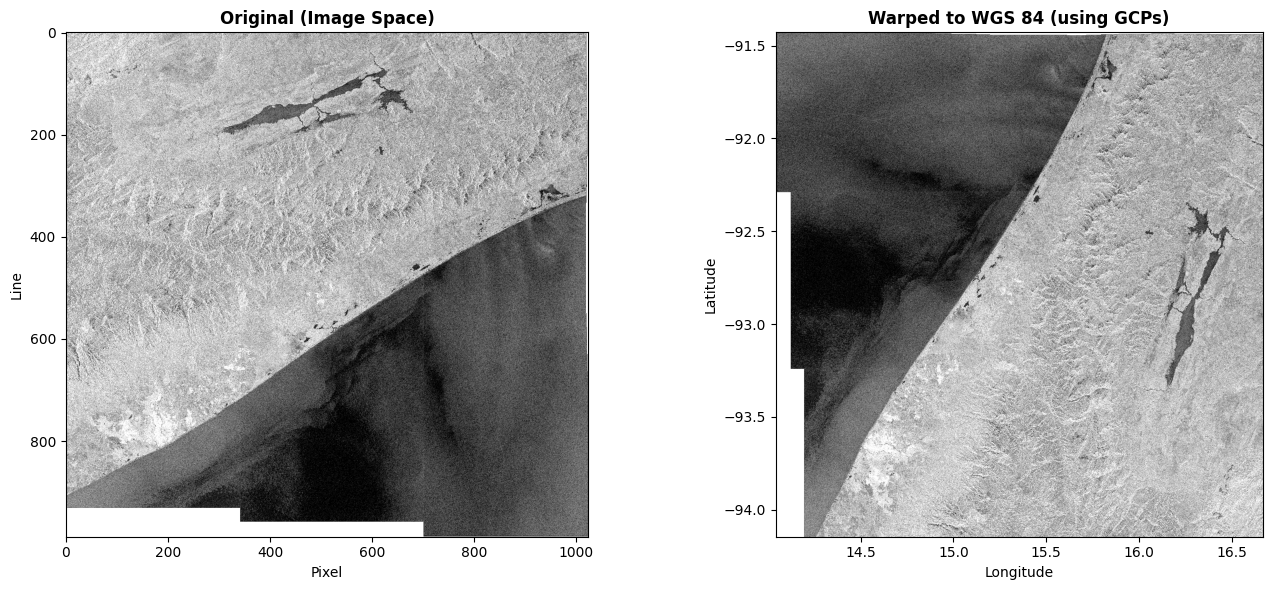

In [17]:
# Warp a small subset to WGS 84 using GCPs
# We use a reduced resolution to keep it fast over /vsicurl/
warped = gdal.Warp(
    "",
    ds,
    format="MEM",
    dstSRS="EPSG:4326",
    width=1024,
    height=0,  # auto-compute from aspect ratio
    resampleAlg="near",
)

if warped:
    gt = warped.GetGeoTransform()
    print(f"Warped dataset: {warped.RasterXSize} x {warped.RasterYSize} pixels")
    print(
        f"GeoTransform:   origin=({gt[0]:.4f}, {gt[3]:.4f}), "
        f"pixel size=({gt[1]:.6f}, {gt[5]:.6f})"
    )
    print(f"Projection:     {warped.GetProjection()[:60]}...")

    try:
        data = warped.GetRasterBand(1).ReadAsArray()
        data_float = data.astype(np.float32)
        data_float[data_float == 0] = np.nan
        data_db = 10 * np.log10(data_float + 1)

        # Compute extent from geotransform
        extent = [
            gt[0],
            gt[0] + gt[1] * warped.RasterXSize,
            gt[3] + gt[5] * warped.RasterYSize,
            gt[3],
        ]

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Original (pixel space)
        orig_sub = ds.GetRasterBand(1).ReadAsArray(
            buf_xsize=1024,
            buf_ysize=int(1024 * ds.RasterYSize / ds.RasterXSize),
        )
        orig_float = orig_sub.astype(np.float32)
        orig_float[orig_float == 0] = np.nan
        orig_db = 10 * np.log10(orig_float + 1)
        vmin, vmax = np.nanpercentile(orig_db, [2, 98])
        axes[0].imshow(orig_db, cmap="gray", vmin=vmin, vmax=vmax)
        axes[0].set_title("Original (Image Space)", fontweight="bold")
        axes[0].set_xlabel("Pixel")
        axes[0].set_ylabel("Line")

        # Warped (geographic space)
        vmin, vmax = np.nanpercentile(data_db, [2, 98])
        axes[1].imshow(data_db, cmap="gray", vmin=vmin, vmax=vmax, extent=extent)
        axes[1].set_title("Warped to WGS 84 (using GCPs)", fontweight="bold")
        axes[1].set_xlabel("Longitude")
        axes[1].set_ylabel("Latitude")

        plt.tight_layout()
        plt.show()
    except ImportError:
        print("ReadAsArray not available (NumPy version mismatch), skipping plot")

    warped = None
else:
    print("Warp failed")

(SLCBursts)=
## GCPs on SLC Burst Subdatasets

GCPs also work on SLC burst subdatasets. Let's verify with a quick check.


In [18]:
SLC_URL = (
    "/vsicurl/https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:"
    "notebook-data/tutorial_data/cpm_v262/"
    "S1C_IW_SLC__1SDV_20251016T165627_20251016T165654_004590_00913B_30C4.zarr"
)

ds_slc = gdal.OpenEx(
    f"EOPFZARR:'{SLC_URL}'", gdal.OF_RASTER, open_options=["BURST=IW1_VV_001"]
)

if ds_slc:
    slc_gcp_count = ds_slc.GetGCPCount()
    slc_srs = ds_slc.GetGCPSpatialRef()
    print("SLC Burst IW1_VV_001:")
    print(f"  Dimensions: {ds_slc.RasterXSize} x {ds_slc.RasterYSize}")
    print(f"  GCP Count:  {slc_gcp_count}")
    if slc_srs:
        print(f"  GCP SRS:    {slc_srs.GetName()}")

    if slc_gcp_count > 0:
        slc_gcps = ds_slc.GetGCPs()
        slc_lons = [g.GCPX for g in slc_gcps]
        slc_lats = [g.GCPY for g in slc_gcps]
        print(
            f"  Extent:     lon [{min(slc_lons):.4f}, {max(slc_lons):.4f}]"
            f"  lat [{min(slc_lats):.4f}, {max(slc_lats):.4f}]"
        )

    ds_slc = None
else:
    print("Failed to open SLC burst")

SLC Burst IW1_VV_001:
  Dimensions: 23261 x 1501
  GCP Count:  210
  GCP SRS:    WGS 84
  Extent:     lon [12.9673, 14.4821]  lat [40.0726, 41.7453]


(CommandLine)=
## Command Line Usage

GCPs are visible via `gdalinfo` on a **measurement subdataset** (not the root dataset). You need to open a specific subdataset path to see the GCPs.


In [19]:
# Print the actual subdataset path used in this notebook
subds_path = vv_path.split("'")[1] if "'" in vv_path else vv_path

print("Step 1: List subdatasets\n")
print(f"  gdalinfo \"EOPFZARR:'{GRD_URL}'\" -oo GRD_MULTIBAND=NO\n")
print("Step 2: Open a measurement subdataset to see GCPs\n")
print(f"  gdalinfo '{subds_path}'\n")
print("The output will include:")
print('  GCP Projection = GEOGCS["WGS 84", ...]')
print("  GCP[  0]: Id=GCP_1, Info=")
print("            (0.5,0.5) -> (-91.4153, 16.2326, 574.99)")
print("  GCP[  1]: Id=GCP_2, Info=")
print("            (1258.5,0.5) -> (-91.5360, 16.2558, 904.98)")
print("  ...")

Step 1: List subdatasets

  gdalinfo "EOPFZARR:'/vsicurl/https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:notebook-data/tutorial_data/cpm_v264/S1C_IW_GRDH_1SDV_20260205T120122_20260205T120158_006220_00C7E4_5D6E.zarr'" -oo GRD_MULTIBAND=NO

Step 2: Open a measurement subdataset to see GCPs

  gdalinfo 'EOPFZARR:"/vsicurl/https://objects.eodc.eu/e05ab01a9d56408d82ac32d69a5aae2a:notebook-data/tutorial_data/cpm_v264/S1C_IW_GRDH_1SDV_20260205T120122_20260205T120158_006220_00C7E4_5D6E.zarr":/S01SIWGRD_20260205T120122_0036_C036_5D6E_00C7E4_VV/measurements/grd'

The output will include:
  GCP Projection = GEOGCS["WGS 84", ...]
  GCP[  0]: Id=GCP_1, Info=
            (0.5,0.5) -> (-91.4153, 16.2326, 574.99)
  GCP[  1]: Id=GCP_2, Info=
            (1258.5,0.5) -> (-91.5360, 16.2558, 904.98)
  ...


(Summary)=
## Summary

### GCP Geolocation Features

| Feature | Description |
|---------|-------------|
| **Automatic Extraction** | GCPs read from `conditions/gcp/` arrays (pixel, line, latitude, longitude, height) |
| **GCP SRS** | WGS 84 (EPSG:4326) with traditional GIS axis ordering (lon, lat) |
| **GRD Coverage** | ~294 GCPs (14 x 21 sparse grid) per subdataset |
| **SLC Coverage** | ~210 GCPs (10 x 21 sparse grid) per burst |
| **GDAL API** | `GetGCPCount()`, `GetGCPs()`, `GetGCPSpatialRef()` |
| **Reprojection** | `gdal.Warp()` uses GCPs automatically for coordinate transformation |

### How It Works

1. When a measurement subdataset is opened, the driver navigates up to the product root
2. It opens the five GCP arrays: `conditions/gcp/{pixel, line, latitude, longitude, height}`
3. The 1D `pixel`/`line` arrays and 2D `latitude`/`longitude`/`height` arrays are cross-referenced to build GDAL GCP structs
4. GCPs are lazily loaded on first access to `GetGCPCount()`, `GetGCPs()`, or `GetGCPSpatialRef()`

### Usage

```python
# Open a GRD subdataset - GCPs are automatically available
ds = gdal.Open(subdataset_path)
print(ds.GetGCPCount())         # e.g. 294
print(ds.GetGCPSpatialRef())    # WGS 84

# Reproject using GCPs
warped = gdal.Warp('output.tif', ds, dstSRS='EPSG:4326')

# Or use BURST for SLC
ds = gdal.OpenEx("EOPFZARR:'/vsicurl/...SLC...zarr'",
                 open_options=["BURST=IW1_VV_001"])
print(ds.GetGCPCount())         # e.g. 210
```


(Cleanup)=
## Cleanup


In [20]:
ds = None
print("All datasets closed")

All datasets closed
